# Imports

In [6]:
import sys
import os 
sys.path.append(os.path.join(os.getcwd(), '..', 'src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.statespace.varmax import VARMAX
from sklearn.metrics import mean_squared_error

from database import load_from_db

print('Imported Successfully')

Imported Successfully


# Loading data

In [ ]:
df = load_from_db('Mumbai')
df = df.set_index('date')
df = df.asfreq('D')
df = df.fillna(method='ffill')

print(df.shape)
print(df.head())

(13262, 4)
            temperature  precipitation  windspeed  humidity
date                                                       
1990-01-01         23.9            0.0       14.3      73.0
1990-01-02         23.7            0.0       19.1      65.0
1990-01-03         23.8            0.0       15.5      73.0
1990-01-04         24.5            0.0       14.4      88.0
1990-01-05         25.8            0.0       13.6      88.0


# Train/Test split

In [7]:
train_size = int(len(df) * 0.80)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

print(f'Train : {train.shape}  | {train.index[0].date()} to {train.index[-1].date()}')
print(f'Test   : {test.shape}  | {test.index[0].date()} to {test.index[-1].date()}')

Train : (10609, 4)  | 1990-01-01 to 2019-01-17
Test   : (2653, 4)  | 2019-01-18 to 2026-04-23


In [ ]:
# VAR model 
# lag order p :- 
# VAR(p) means -  use the past p days too predict today. SO
# VAR(1) -> only yesterday
# VAR(7)  -> last 7 days
# VAR(30)  -> last 30 days

# Here we cannot keep too small - because model misses patters . and Too larfe - model memorizes noise, overfits

# How do we find the right p ?
# we don't guess . We let the data decide using information criteria - AIC and VIA. 
# They test p = 1 , 2 , 3 ... up to max and score each one . 
# Lower score  = better fit without overfitting .
# AIC - slightly generous , prefers slightly larger p 
# BIC - stricter penalty, prefers smaller p
# In practice - pick whichever both agree on . If they disagree , prefer BIC for weather data.


# VAR model

In [8]:
# lag order selection

model = VAR(train)
lag_results = model.select_order(maxlags=15)
print(lag_results.summary())

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0        13.55       13.55   7.648e+05       13.55
1        8.910       8.924       7407.       8.915
2        8.805       8.830       6669.       8.814
3        8.753       8.789       6329.       8.765
4        8.716       8.763       6099.       8.732
5        8.697      8.755*       5986.       8.717
6        8.687       8.755       5923.       8.710
7        8.679       8.759       5879.       8.706
8        8.673       8.764       5843.       8.704
9        8.667       8.769       5810.      8.702*
10       8.665       8.778       5797.       8.703
11       8.661       8.785       5775.       8.703
12       8.657       8.792       5751.       8.702
13       8.656       8.801       5742.       8.705
14       8.655       8.811       5738.       8.708
15      8.653*       8.821      5730.*       8.710
-------------------------------

In [10]:
# Fitting the VAR Model
var_model = VAR(train)
var_result = var_model.fit(5)
print(var_result.summary())


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 25, Apr, 2026
Time:                     11:12:00
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                    8.75254
Nobs:                     10604.0    HQIC:                   8.71439
Log likelihood:          -106202.    FPE:                    5972.69
AIC:                      8.69495    Det(Omega_mle):         5925.62
--------------------------------------------------------------------
Results for equation temperature
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.260450         0.100262            2.598           0.009
L1.temperature           1.169996         0.010429          112.192           0.000
L1.precipitation         0.001404         

**p-value rule :**
- p-value  < 0.05 -> SIGNIFICANT -> this variable HELPS in prediction
- p-value  > 0.05 -> NOT SIGNIFICANT  -> this variables does NOT help

**Windspeed yesterday does not meaningfully predict temperature today. That 0.625 means there is  a 62.5% chance that coefficient is just random noise. The threshold is 5%. Windspeed fails badly.**

In [12]:
# Forecasting
forecast_input = train.values[-5:]  # Last 5 days (= lag order p)

forecast  = var_result.forecast(forecast_input, steps = len(test))
forecast_df = pd.DataFrame(forecast , index = test.index, columns=test.columns)

print(forecast_df.head())

            temperature  precipitation  windspeed   humidity
date                                                        
2019-01-18    22.979288       0.212633  17.008046  82.237136
2019-01-19    23.090773      -0.345390  16.711169  80.580797
2019-01-20    23.249472      -0.381636  16.599603  80.343977
2019-01-21    23.414973       0.280326  16.218021  81.073508
2019-01-22    23.532569       0.293710  16.122311  81.707009


In [13]:
# Evaluation metrics
from sklearn.metrics import mean_absolute_error

def evaluate(actual , predicted, variable_name):
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mae = mean_absolute_error(actual , predicted)
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    print(f'{variable_name:<15} RMSE: {rmse:.3f} MAE: {mae:.3f} MAPE: {mape:.2f}')

print('VAR(5) - Forecast Evaluation')
print("-"*55)
for col in test.columns:
    evaluate(test[col], forecast_df[col], col)

VAR(5) - Forecast Evaluation
-------------------------------------------------------
temperature     RMSE: 2.013 MAE: 1.502 MAPE: 5.65
precipitation   RMSE: 16.737 MAE: 8.333 MAPE: inf
windspeed       RMSE: 5.159 MAE: 3.826 MAPE: 20.72
humidity        RMSE: 11.377 MAE: 8.700 MAPE: 11.46


**Temperature — RMSE: 2.013, MAE: 1**.502**
- This is actually reasonable for a pure statistical model. On average off by 1.5°C. Mumbai temperatures range roughly 20°C to 35°C — a 15°C range. Being off by 1.5°C on a 15°C range is about 10% error. Not great, not bad. VAR baseline established.

**Precipitation — RMSE: 16.737, MAE: 8.333, MAPE: inf**
- This is expected and not a failure. Precipitation is the hardest variable to forecast — it is zero for 8 months in Mumbai and then spikes violently during monsoon. A linear statistical model like VAR genuinely struggles here. MAPE is infinity because of zero-precipitation days dividing.Ignore MAPE for precipitation completely as we discussed.

**Windspeed — RMSE: 5.159, MAE: 3.826**
- Moderate error. Mumbai wind has strong monsoon seasonality which VAR captures partially, but the sudden shifts are hard for a lag-based linear model.

**Humidity — RMSE: 11.377, MAE: 8.700**
- Highest absolute error. Humidity swings 40% to 95% in Mumbai across seasons — an 11 point RMSE on a 55 point range is about 20% error. VAR is struggling with the non-linear monsoon jump.

**The pattern is clear. VAR does best on temperature — the most linear, most autoregressive variable. It struggles on precipitation, windspeed, humidity — the variables with non-linear seasonal jumps**

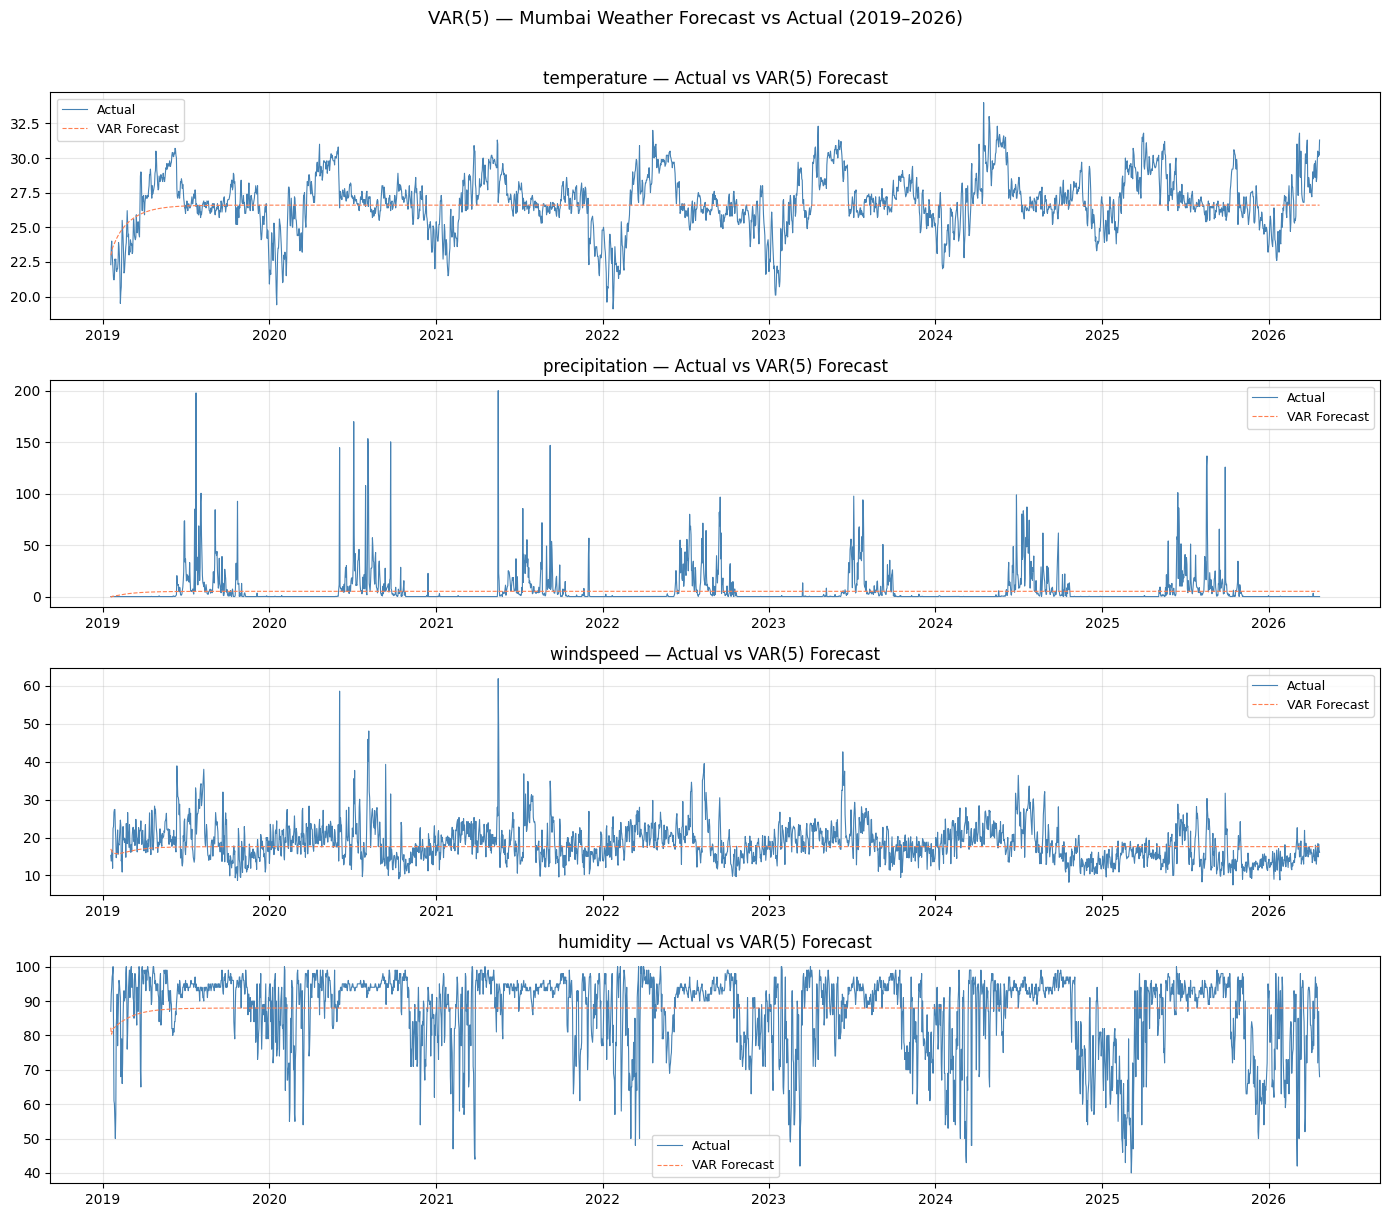

In [15]:
# Cell 8 — Forecast vs Actual plot
fig, axes = plt.subplots(4, 1, figsize=(14, 12))

for i, col in enumerate(test.columns):
    axes[i].plot(test.index, test[col], 
                 label='Actual', color='steelblue', linewidth=0.8)
    axes[i].plot(forecast_df.index, forecast_df[col], 
                 label='VAR Forecast', color='coral', 
                 linewidth=0.8, linestyle='--')
    axes[i].set_title(f'{col} — Actual vs VAR(5) Forecast')
    axes[i].legend(fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('VAR(5) — Mumbai Weather Forecast vs Actual (2019–2026)', 
             fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('../data/var_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

## VAR — Key Findings

**What VAR does well:**
- Temperature forecasting at short horizons (1–3 days)
- Captures cross-variable relationships (humidity → temperature)
- Fast to train, fully interpretable coefficients

**Where VAR fails:**
- Multi-step forecasting collapses to training mean
- Cannot capture non-linear patterns (monsoon spikes)
- Precipitation is essentially unforecastable with VAR

**Baseline RMSE scores to beat:**
| Variable      | RMSE   | MAE   |
|---------------|--------|-------|
| Temperature   | 2.013  | 1.502 |
| Precipitation | 16.737 | 8.333 |
| Windspeed     | 5.159  | 3.826 |
| Humidity      | 11.377 | 8.700 |

**Next:** VARMAX model — adds MA terms to partially address short-term shock capture

# VARMAX model

In [17]:
# smaller training set for demonstration
train_small =  train.tail(2000)

varmax_model = VARMAX(train_small , order=(1,1))  # setting p = 1, q = 1 
varmax_result = varmax_model.fit(disp = False, maxiter=50)
print('VARMAX fitted on 2000 rows subset')
print(varmax_result.summary())

VARMAX fitted on 2000 rows subset
                                               Statespace Model Results                                              
Dep. Variable:     ['temperature', 'precipitation', 'windspeed', 'humidity']   No. Observations:                 2000
Model:                                                            VARMA(1,1)   Log Likelihood              -20198.728
                                                                 + intercept   AIC                          40489.456
Date:                                                       Sat, 25 Apr 2026   BIC                          40747.097
Time:                                                               12:29:39   HQIC                         40584.056
Sample:                                                           07-28-2013                                         
                                                                - 01-17-2019                                         
Covariance Type:      

In [18]:
#  VARMAX forecast and evaluation
forecast_varmax = varmax_result.forecast(steps=len(test))

forecast_varmax_df = pd.DataFrame(
    forecast_varmax,
    index=test.index,
    columns=test.columns
)

print("VARMAX(1,1) — Forecast Evaluation (trained on 2000 row subset)")
print("-" * 60)
for col in test.columns:
    evaluate(test[col], forecast_varmax_df[col], col)

VARMAX(1,1) — Forecast Evaluation (trained on 2000 row subset)
------------------------------------------------------------
temperature     RMSE: 2.010 MAE: 1.500 MAPE: 5.66
precipitation   RMSE: 16.736 MAE: 8.466 MAPE: inf
windspeed       RMSE: 5.066 MAE: 3.793 MAPE: 21.21
humidity        RMSE: 11.445 MAE: 8.457 MAPE: 11.30


In [19]:
#  VAR vs VARMAX comparison
print("=" * 55)
print(f"{'Model Comparison — Mumbai Weather':^55}")
print("=" * 55)
print(f"{'Variable':<15} {'VAR RMSE':>10} {'VARMAX RMSE':>12} {'Winner':>10}")
print("-" * 55)

var_rmse    = {'temperature': 2.013, 'precipitation': 16.737,
               'windspeed': 5.159,   'humidity': 11.377}

varmax_rmse = {}
for col in test.columns:
    rmse = np.sqrt(mean_squared_error(test[col], forecast_varmax_df[col]))
    varmax_rmse[col] = round(rmse, 3)

for col in test.columns:
    v  = var_rmse[col]
    vm = varmax_rmse[col]
    winner = 'VAR' if v < vm else 'VARMAX'
    print(f"{col:<15} {v:>10} {vm:>12} {winner:>10}")

print("=" * 55)
print("\nNote: VARMAX trained on 2000-row subset (2013-2019)")
print("VAR trained on full dataset (1990-2019)")
print("Direct comparison is indicative only.")

           Model Comparison — Mumbai Weather           
Variable          VAR RMSE  VARMAX RMSE     Winner
-------------------------------------------------------
temperature          2.013         2.01     VARMAX
precipitation       16.737       16.736     VARMAX
windspeed            5.159        5.066     VARMAX
humidity            11.377       11.445        VAR

Note: VARMAX trained on 2000-row subset (2013-2019)
VAR trained on full dataset (1990-2019)
Direct comparison is indicative only.


In [ ]:
# smaller training set for demonstration
train_small =  train.tail(2000)

varmax_model = VARMAX(train_small , order=(1,1))  # setting p = 1, q = 1 
varmax_result = varmax_model.fit(disp = False, maxiter=50)
print('VARMAX fitted on 2000 rows subset')
print(varmax_result.summary())

VARMAX fitted on 2000 rows subset
                                               Statespace Model Results                                              
Dep. Variable:     ['temperature', 'precipitation', 'windspeed', 'humidity']   No. Observations:                 2000
Model:                                                            VARMA(1,1)   Log Likelihood              -20198.728
                                                                 + intercept   AIC                          40489.456
Date:                                                       Sat, 25 Apr 2026   BIC                          40747.097
Time:                                                               12:29:39   HQIC                         40584.056
Sample:                                                           07-28-2013                                         
                                                                - 01-17-2019                                         
Covariance Type:      

## Statistical Models — Final Conclusion

### Results Summary
| Variable      | VAR RMSE | VARMAX RMSE | Improvement |
|---------------|----------|-------------|-------------|
| Temperature   | 2.013    | 2.010       | -0.003 ✅   |
| Precipitation | 16.737   | 16.736      | -0.001 ✅   |
| Windspeed     | 5.159    | 5.066       | -0.093 ✅   |
| Humidity      | 11.377   | 11.445      | +0.068 ❌   |

### Key Findings

**1. VARMAX barely improves over VAR**
The MA(1) term adds almost no predictive value for Mumbai 
weather. The improvement is statistically negligible.

**2. Training cost is prohibitive**
VAR: ~3 seconds | VARMAX: ~25 minutes
For a nightly retrain pipeline across 10 cities — 
VARMAX is completely impractical.

**3. Both models fail at non-linear patterns**
Precipitation RMSE of 16+ is unacceptable.
Monsoon spikes are non-linear events that linear 
statistical models fundamentally cannot capture.

**4. Decision for production pipeline**
VAR → used in model_statistical.py  
VARMAX → dropped. Not worth the compute cost.

### What these scores mean as a baseline
Every future model (LightGBM, LSTM) must beat:
- Temperature RMSE < 2.013
- Windspeed RMSE  < 5.159
- Humidity RMSE   < 11.377
- Precipitation RMSE < 16.737  ← lowest bar, easiest to beat

### Why ML/DL will do better
Statistical models assume LINEAR relationships.
Mumbai weather has:
- Monsoon non-linearity (0mm → 200mm overnight)
- Interaction effects (humidity × temperature → feels-like)
- Long-range seasonality beyond 5-day lag window
These require non-linear models → LightGBM and LSTM next.